# LUT Spline Derivative Check

Lightweight sanity check for the FLM lookup-table time reparameterization. In `utils.build_luts`, the raw grid is `t -> tau`; the returned `lut_g2a` is the `t -> tau` spline, and `lut_a2g` is the inverse `tau -> t` spline. This is the same derivative used by `FLM._d_tau_by_d_t` via `utils.d_alpha_by_d_gamma(t, self.lut_g2a)`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import utils

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=6, suppress=True)
torch.set_default_dtype(torch.float64)

/share/kuleshov/yzs2/myconda/envs/flm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Controls

Keep `N_FIT` modest while iterating. The code uses the same `utils.compute_alpha_exact` and `utils.build_luts` helpers as the training code path.

In [11]:
K = 50_257
N_FIT = 2_000
N_DENSE = 2_000
IS_DIFFUSION = False

# Clip the inverse-derivative view so endpoint spikes do not hide the middle.
DT_DTAU_TAU_MIN = 1e-1
DT_DTAU_TAU_MAX = 1.0 - 1e-2

# A few explicit probe points for the round-trip table and curve markers.
TAU_PROBES = np.array([
    0.0, 1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.25,
    0.5, 0.75, 0.9, 0.99, 0.999, 1.0,
], dtype=np.float64)

## Build the LUTs

`t_fit` is the original uniform grid. `tau_fit` is the Gauss-Hermite quantity computed on that grid. The cubic splines are then fit in both directions.

In [12]:
t_fit = np.linspace(0.0, 1.0, N_FIT, dtype=np.float64)
tau_fit = utils.compute_alpha_exact(t_fit, K=K, is_diffusion=IS_DIFFUSION)

# Same construction used by FLMBase.__init__.
tau_to_t_spline, t_to_tau_spline = utils.build_luts(
    K=K,
    n_points=N_FIT,
    is_diffusion=IS_DIFFUSION,
)

t_dense = np.linspace(0.0, 1.0, N_DENSE, dtype=np.float64)
tau_exact_dense = utils.compute_alpha_exact(t_dense, K=K, is_diffusion=IS_DIFFUSION)
tau_spline_dense = utils.gamma_to_alpha(t_dense, t_to_tau_spline)

tau_dense = np.linspace(0.0, 1.0, N_DENSE, dtype=np.float64)
t_spline_dense = utils.alpha_to_gamma(tau_dense, tau_to_t_spline)

print(f"fit points: {N_FIT:,}")
print(f"unique tau knots in inverse spline: {len(tau_to_t_spline.x):,}")
print(f"max |tau_exact(t) - tau_spline(t)|: {np.max(np.abs(tau_exact_dense - tau_spline_dense)):.3e}")

fit points: 2,000
unique tau knots in inverse spline: 2,000
max |tau_exact(t) - tau_spline(t)|: 0.000e+00


## Function Fit

Left: raw `t -> tau` table and the fitted spline used by `utils.gamma_to_alpha`. Right: the inverse `tau -> t` spline used by `utils.alpha_to_gamma`.

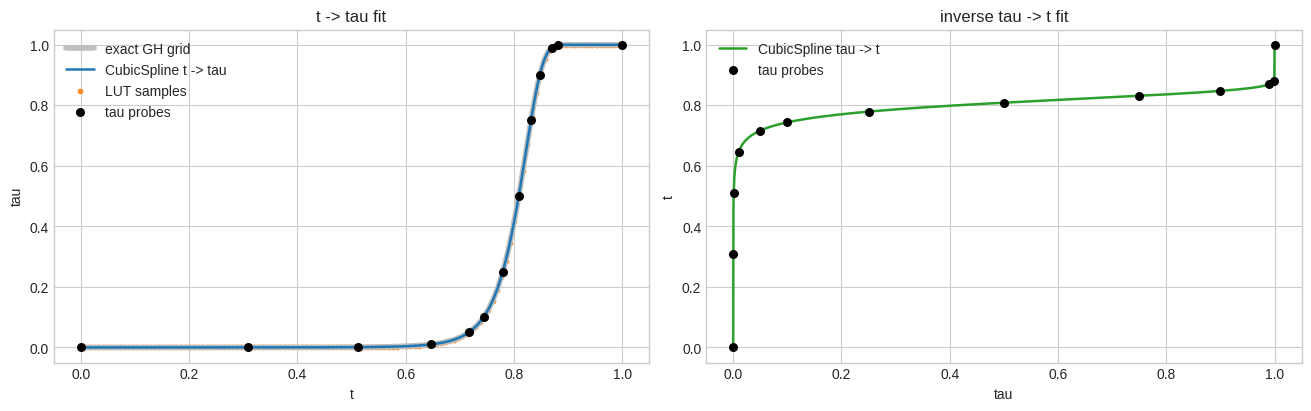

In [13]:
probe_t = utils.alpha_to_gamma(TAU_PROBES, tau_to_t_spline)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].plot(t_dense, tau_exact_dense, color="0.75", lw=4, label="exact GH grid")
axes[0].plot(t_dense, tau_spline_dense, color="C0", lw=1.8, label="CubicSpline t -> tau")
axes[0].scatter(t_fit[:: max(1, N_FIT // 120)], tau_fit[:: max(1, N_FIT // 120)], s=10, color="C1", alpha=0.8, label="LUT samples")
axes[0].scatter(probe_t, TAU_PROBES, s=30, color="black", zorder=5, label="tau probes")
axes[0].set_xlabel("t")
axes[0].set_ylabel("tau")
axes[0].set_title("t -> tau fit")
axes[0].legend()

axes[1].plot(tau_dense, t_spline_dense, color="C2", lw=1.8, label="CubicSpline tau -> t")
axes[1].scatter(TAU_PROBES, probe_t, s=30, color="black", zorder=5, label="tau probes")
axes[1].set_xlabel("tau")
axes[1].set_ylabel("t")
axes[1].set_title("inverse tau -> t fit")
axes[1].legend()

plt.show()

## Derivative Check

`utils.d_alpha_by_d_gamma(t, lut_g2a)` is the derivative of the `t -> tau` spline. It should align with a finite-difference derivative of the exact lookup curve. Away from saturated endpoints, it should also match the reciprocal of `d t / d tau` from the inverse spline.

In [14]:
dtau_dt_spline = utils.d_alpha_by_d_gamma(t_dense, t_to_tau_spline)
dtau_dt_fd_exact = np.gradient(tau_exact_dense, t_dense, edge_order=2)

# Reciprocal consistency: if t = f(tau), then d tau / d t = 1 / f'(tau(t)).
dt_dtau_at_tau_of_t = tau_to_t_spline.derivative()(tau_spline_dense)
with np.errstate(divide="ignore", invalid="ignore"):
    dtau_dt_reciprocal = 1.0 / dt_dtau_at_tau_of_t

# Endpoints can saturate and make reciprocal checks ill-conditioned.
interior = (
    (t_dense > 1e-4)
    & (t_dense < 1.0 - 1e-4)
    & (tau_spline_dense > 1e-6)
    & (tau_spline_dense < 1.0 - 1e-6)
    & np.isfinite(dtau_dt_reciprocal)
)

print(f"max |spline derivative - finite-diff exact|: {np.max(np.abs(dtau_dt_spline - dtau_dt_fd_exact)):.3e}")
print(f"max interior |d tau/dt - 1/(d t/dtau)|: {np.max(np.abs(dtau_dt_spline[interior] - dtau_dt_reciprocal[interior])):.3e}")
print(f"median interior |d tau/dt - 1/(d t/dtau)|: {np.median(np.abs(dtau_dt_spline[interior] - dtau_dt_reciprocal[interior])):.3e}")

max |spline derivative - finite-diff exact|: 1.147e-03
max interior |d tau/dt - 1/(d t/dtau)|: 3.132e-06
median interior |d tau/dt - 1/(d t/dtau)|: 6.847e-13


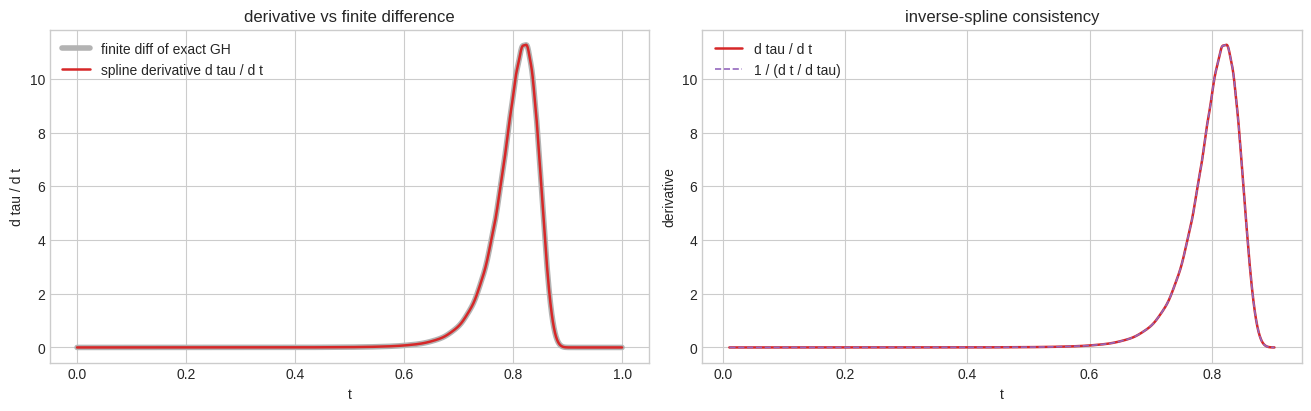

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].plot(t_dense, dtau_dt_fd_exact, color="0.70", lw=4, label="finite diff of exact GH")
axes[0].plot(t_dense, dtau_dt_spline, color="C3", lw=1.8, label="spline derivative d tau / d t")
axes[0].set_xlabel("t")
axes[0].set_ylabel("d tau / d t")
axes[0].set_title("derivative vs finite difference")
axes[0].legend()

axes[1].plot(t_dense[interior], dtau_dt_spline[interior], color="C3", lw=1.8, label="d tau / d t")
axes[1].plot(t_dense[interior], dtau_dt_reciprocal[interior], color="C4", lw=1.2, ls="--", label="1 / (d t / d tau)")
axes[1].set_xlabel("t")
axes[1].set_ylabel("derivative")
axes[1].set_title("inverse-spline consistency")
axes[1].legend()

plt.show()

## Inverse Derivative Check

This is the mirrored view for d t / d tau. The direct curve is the derivative of the inverse tau -> t spline. The finite-difference line checks that inverse spline numerically, and the reciprocal line checks consistency with the forward d tau / d t spline. The plots use DT_DTAU_TAU_MIN and DT_DTAU_TAU_MAX to clip away endpoint spikes so the middle range is readable.


In [16]:
dt_dtau_spline = tau_to_t_spline.derivative()(tau_dense)
dt_dtau_fd_inverse = np.gradient(t_spline_dense, tau_dense, edge_order=2)

# Reciprocal consistency: if tau = g(t), then d t / d tau = 1 / g'(t(tau)).
dtau_dt_at_t_of_tau = t_to_tau_spline.derivative()(t_spline_dense)
with np.errstate(divide="ignore", invalid="ignore"):
    dt_dtau_reciprocal = 1.0 / dtau_dt_at_t_of_tau

interior_tau = (
    (tau_dense > 1e-6)
    & (tau_dense < 1.0 - 1e-6)
    & (t_spline_dense > 1e-4)
    & (t_spline_dense < 1.0 - 1e-4)
    & np.isfinite(dt_dtau_reciprocal)
)

dt_dtau_view = (
    interior_tau
    & (tau_dense >= DT_DTAU_TAU_MIN)
    & (tau_dense <= DT_DTAU_TAU_MAX)
)

print(f"d t/dtau view tau range: [{DT_DTAU_TAU_MIN:g}, {DT_DTAU_TAU_MAX:g}]")
print(f"max view |inverse spline derivative - finite-diff inverse|: {np.max(np.abs(dt_dtau_spline[dt_dtau_view] - dt_dtau_fd_inverse[dt_dtau_view])):.3e}")
print(f"max view |d t/dtau - 1/(d tau/dt)|: {np.max(np.abs(dt_dtau_spline[dt_dtau_view] - dt_dtau_reciprocal[dt_dtau_view])):.3e}")
print(f"median view |d t/dtau - 1/(d tau/dt)|: {np.median(np.abs(dt_dtau_spline[dt_dtau_view] - dt_dtau_reciprocal[dt_dtau_view])):.3e}")


d t/dtau view tau range: [0.1, 0.99]
max view |inverse spline derivative - finite-diff inverse|: 4.247e-04
max view |d t/dtau - 1/(d tau/dt)|: 9.170e-06
median view |d t/dtau - 1/(d tau/dt)|: 9.013e-09


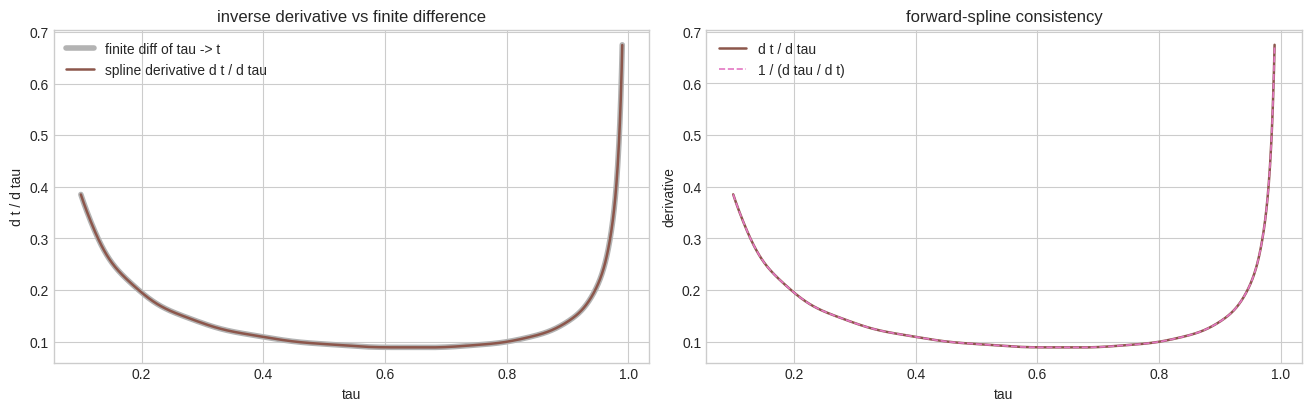

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].plot(tau_dense[dt_dtau_view], dt_dtau_fd_inverse[dt_dtau_view], color="0.70", lw=4, label="finite diff of tau -> t")
axes[0].plot(tau_dense[dt_dtau_view], dt_dtau_spline[dt_dtau_view], color="C5", lw=1.8, label="spline derivative d t / d tau")
axes[0].set_xlabel("tau")
axes[0].set_ylabel("d t / d tau")
axes[0].set_title("inverse derivative vs finite difference")
axes[0].legend()

axes[1].plot(tau_dense[dt_dtau_view], dt_dtau_spline[dt_dtau_view], color="C5", lw=1.8, label="d t / d tau")
axes[1].plot(tau_dense[dt_dtau_view], dt_dtau_reciprocal[dt_dtau_view], color="C6", lw=1.2, ls="--", label="1 / (d tau / d t)")
axes[1].set_xlabel("tau")
axes[1].set_ylabel("derivative")
axes[1].set_title("forward-spline consistency")
axes[1].legend()

plt.show()


## Probe Values

This table uses the same helper functions as the model methods: `alpha_to_gamma` for `tau -> t`, `gamma_to_alpha` for `t -> tau`, and `d_alpha_by_d_gamma` for `d tau / d t`.

In [9]:
probe_tau = TAU_PROBES
probe_t = utils.alpha_to_gamma(probe_tau, tau_to_t_spline)
probe_tau_roundtrip = utils.gamma_to_alpha(probe_t, t_to_tau_spline)
probe_dtau_dt = utils.d_alpha_by_d_gamma(probe_t, t_to_tau_spline)

header = f"{'tau':>12} {'t = tau_to_t(tau)':>22} {'roundtrip tau':>18} {'abs err':>12} {'d tau / d t':>14}"
print(header)
print("-" * len(header))
for tau, t, tau_rt, deriv in zip(probe_tau, probe_t, probe_tau_roundtrip, probe_dtau_dt):
    print(f"{tau:12.6g} {t:22.12g} {tau_rt:18.12g} {abs(tau_rt - tau):12.3e} {deriv:14.6g}")

         tau      t = tau_to_t(tau)      roundtrip tau      abs err    d tau / d t
----------------------------------------------------------------------------------
           0                      0  9.40312257761e-08    9.403e-08     8.4917e-05
      0.0001         0.308700080001             0.0001    1.133e-17    0.000944121
       0.001          0.51193962397  0.000999999999997    2.533e-15      0.0138274
        0.01         0.646459123102    0.0100000000024    2.392e-12       0.209564
        0.05         0.716598648594    0.0500000000442    4.418e-11        1.25717
         0.1         0.743769640197     0.100000000025    2.507e-11        2.59473
        0.25         0.779237551441     0.250000000139    1.387e-10           6.32
         0.5         0.808741022229     0.499999999993    6.882e-12        10.4811
        0.75         0.831366516244     0.750000000008    8.386e-12        10.6942
         0.9         0.847652112274     0.899999999306    6.944e-10        7.20866
    

## Torch Helper Smoke Test

The NumPy and Torch helper paths should agree up to dtype precision. This mirrors how the model calls these helpers with tensors.

In [10]:
t_torch = torch.linspace(0.0, 1.0, 21)
tau_torch = utils.gamma_to_alpha(t_torch, t_to_tau_spline)
dtau_dt_torch = utils.d_alpha_by_d_gamma(t_torch, t_to_tau_spline)

tau_numpy = utils.gamma_to_alpha(t_torch.numpy(), t_to_tau_spline)
dtau_dt_numpy = utils.d_alpha_by_d_gamma(t_torch.numpy(), t_to_tau_spline)

print(f"max torch-vs-numpy tau diff: {np.max(np.abs(tau_torch.numpy() - tau_numpy)):.3e}")
print(f"max torch-vs-numpy derivative diff: {np.max(np.abs(dtau_dt_torch.numpy() - dtau_dt_numpy)):.3e}")

max torch-vs-numpy tau diff: 0.000e+00
max torch-vs-numpy derivative diff: 0.000e+00
